# Kaggle – Data on the top
Tu profe ha decidido cambiar de aires y, por eso, ha comprado una tienda de portátiles. Sin embargo, su única especialidad es Data Science, por lo que ha decidido crear un modelo de ML para establecer los mejores precios.

¿Podrías ayudar a tu profe a mejorar ese modelo?

## Métrica: RMSE

$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

Donde $y_i$ es el valor real y $\hat{y}_i$ es el valor predicho. **Cuanto menor, mejor.**

---
# PARTE 1: Entrenamiento del modelo

## 1. Librerías

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

## 2. Datos

In [3]:
df = pd.read_csv('./data/train.csv', encoding='latin-1')
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_in_euros
0,755,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 10,1.86kg,539.00
1,618,Dell,Inspiron 7559,Gaming,15.6,Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,16GB,1TB HDD,Nvidia GeForce GTX 960<U+039C>,Windows 10,2.59kg,879.01
2,909,HP,ProBook 450,Notebook,15.6,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,8GB,1TB HDD,Nvidia GeForce 930MX,Windows 10,2.04kg,900.00
3,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
4,286,Dell,Inspiron 3567,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,AMD Radeon R5 M430,Linux,2.25kg,428.00


### 2.1 Exploración de los datos

In [4]:
df.shape

(912, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         912 non-null    int64  
 1   Company           912 non-null    object 
 2   Product           912 non-null    object 
 3   TypeName          912 non-null    object 
 4   Inches            912 non-null    float64
 5   ScreenResolution  912 non-null    object 
 6   Cpu               912 non-null    object 
 7   Ram               912 non-null    object 
 8   Memory            912 non-null    object 
 9   Gpu               912 non-null    object 
 10  OpSys             912 non-null    object 
 11  Weight            912 non-null    object 
 12  Price_in_euros    912 non-null    float64
dtypes: float64(2), int64(1), object(10)
memory usage: 92.8+ KB


In [6]:
df.isnull().sum()

laptop_ID           0
Company             0
Product             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price_in_euros      0
dtype: int64

In [7]:
df.describe()

,laptop_ID,Inches,Price_in_euros
count,912.000000,912.000000,912.000000
mean,650.312500,14.981579,1111.724090
std,382.727748,1.436719,687.959172
min,2.000000,10.100000,174.000000
25%,324.750000,14.000000,589.000000
50%,636.500000,15.600000,978.000000
75%,982.250000,15.600000,1483.942500
max,1320.000000,18.400000,6099.000000


<Axes: >

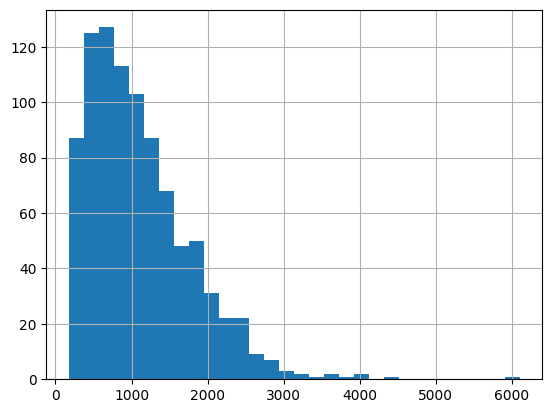

In [8]:
df["Price_in_euros"].hist(bins=30)

In [9]:
df.groupby("Company")["Price_in_euros"].agg(["count", "mean", "median"]).sort_values("median", ascending=False)

,count,mean,median
Company,,,
Razer,6,2987.333333,2749.000
LG,1,2299.000000,2299.000
Google,2,1879.000000,1879.000
Microsoft,5,1716.970000,1799.000
Samsung,5,1423.000000,1699.000
MSI,37,1713.425135,1598.000
Huawei,2,1424.000000,1424.000
Apple,17,1540.322353,1419.000
Toshiba,34,1276.558824,1240.000


In [10]:
df.groupby("TypeName")["Price_in_euros"].agg(["count", "mean", "median"]).sort_values("median", ascending=False)

,count,mean,median
TypeName,,,
Workstation,20,2233.926000,1984.000
Ultrabook,141,1552.962837,1499.000
Gaming,143,1701.052238,1479.000
2 in 1 Convertible,80,1337.643375,1378.495
Notebook,509,766.723674,685.000
Netbook,19,511.673684,295.000


In [11]:
df[df["Company"] == "Apple"][["Company", "Product", "TypeName", "Inches", "Cpu", "Ram", "Memory", "Weight", "Price_in_euros"]]

,Company,Product,TypeName,Inches,Cpu,Ram,Memory,Weight,Price_in_euros
3,Apple,Macbook Air,Ultrabook,13.3,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,1.34kg,898.94
10,Apple,MacBook Pro,Ultrabook,13.3,Intel Core i5 2.9GHz,8GB,512GB SSD,1.37kg,1958.90
59,Apple,"MacBook 12""",Ultrabook,12.0,Intel Core i5 1.3GHz,8GB,512GB SSD,0.92kg,1510.00
76,Apple,MacBook Pro,Ultrabook,13.3,Intel Core i5 3.1GHz,8GB,512GB SSD,1.37kg,2040.00
227,Apple,MacBook Pro,Ultrabook,13.3,Intel Core i5 2.0GHz,8GB,256GB SSD,1.37kg,1419.00
281,Apple,MacBook Air,Ultrabook,11.6,Intel Core i5 1.6GHz,4GB,256GB Flash Storage,1.08kg,959.00
324,Apple,MacBook Pro,Ultrabook,13.3,Intel Core i5 3.1GHz,8GB,256GB SSD,1.37kg,1803.60
334,Apple,"MacBook 12""",Ultrabook,12.0,Intel Core M m3 1.2GHz,8GB,256GB SSD,0.92kg,1262.40
343,Apple,"MacBook 12""",Ultrabook,12.0,Intel Core M 1.1GHz,8GB,256GB Flash Storage,0.920kg,1163.00
473,Apple,MacBook Pro,Ultrabook,15.4,Intel Core i7 2.2GHz,16GB,256GB Flash Storage,2.04kg,2139.97


In [12]:
ultrabooks = df[df["TypeName"] == "Ultrabook"].copy()

ultrabooks["is_apple"] = ultrabooks["Company"] == "Apple"

ultrabooks.groupby("is_apple")["Price_in_euros"].agg(["count", "mean", "median"])

,count,mean,median
is_apple,,,
False,124,1554.695806,1499.5
True,17,1540.322353,1419.0


In [13]:
df.groupby("Ram")["Price_in_euros"].agg(["count", "mean", "median"]).sort_values("median", ascending=False)

,count,mean,median
Ram,,,
64GB,1,3975.000000,3975.000
32GB,10,3443.357000,3148.185
16GB,136,1938.095000,1899.000
24GB,1,1269.000000,1269.000
12GB,19,1287.836842,1249.000
8GB,434,1181.682765,1099.000
6GB,24,635.912083,609.005
4GB,267,573.200824,498.900
2GB,20,250.407500,234.000


In [14]:
df["Memory"].value_counts()

Memory
256GB SSD                        282
1TB HDD                          152
500GB HDD                         92
512GB SSD                         83
128GB SSD +  1TB HDD              67
128GB SSD                         54
256GB SSD +  1TB HDD              52
32GB Flash Storage                33
1TB SSD                           12
64GB Flash Storage                11
512GB SSD +  1TB HDD               8
2TB HDD                            8
256GB Flash Storage                7
16GB Flash Storage                 6
256GB SSD +  2TB HDD               6
32GB SSD                           5
1.0TB Hybrid                       5
128GB Flash Storage                4
180GB SSD                          3
16GB SSD                           3
512GB SSD +  2TB HDD               2
1TB SSD +  1TB HDD                 2
1TB HDD +  1TB HDD                 1
512GB Flash Storage                1
1.0TB HDD                          1
256GB SSD +  500GB HDD             1
8GB SSD                        

In [15]:
df["has_ssd"] = df["Memory"].str.contains("SSD")

df.groupby("has_ssd")["Price_in_euros"].agg(["count", "mean", "median"])

,count,mean,median
has_ssd,,,
False,325,634.253262,549.99
True,587,1376.081874,1262.40


In [16]:
df.nunique().sort_values(ascending=False)

laptop_ID           912
Price_in_euros      603
Product             480
Weight              165
Cpu                 107
Gpu                  93
Memory               37
ScreenResolution     36
Company              19
Inches               17
Ram                   9
OpSys                 9
TypeName              6
has_ssd               2
dtype: int64

In [17]:
df["Ram_num"] = df["Ram"].str.replace("GB", "").astype(int)
df["Weight_num"] = df["Weight"].str.replace("kg", "").astype(float)

df[["Ram", "Ram_num", "Weight", "Weight_num", "has_ssd"]].head()

,Ram,Ram_num,Weight,Weight_num,has_ssd
0,8GB,8,1.86kg,1.86,True
1,16GB,16,2.59kg,2.59,False
2,8GB,8,2.04kg,2.04,False
3,8GB,8,1.34kg,1.34,False
4,4GB,4,2.25kg,2.25,False


### 2.2 Definir X e y


In [18]:
features = ["Company", "TypeName", "OpSys", "Inches", "Ram_num", "Weight_num", "has_ssd"]

X = df[features]
y = df["Price_in_euros"]

X.head()

,Company,TypeName,OpSys,Inches,Ram_num,Weight_num,has_ssd
0,HP,Notebook,Windows 10,15.6,8,1.86,True
1,Dell,Gaming,Windows 10,15.6,16,2.59,False
2,HP,Notebook,Windows 10,15.6,8,2.04,False
3,Apple,Ultrabook,macOS,13.3,8,1.34,False
4,Dell,Notebook,Linux,15.6,4,2.25,False


### 2.3 Dividir en train y test

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((729, 7), (183, 7), (729,), (183,))

## 3. Procesado de datos

> 🚨 **Data leakage:** si usas un scaler, haz **`.fit()` SOLO sobre `X_train`** y luego aplica `.transform()` sobre `X_train` y `X_test` por separado.
>
> Recuerda también que **todo lo que hagas aquí deberás replicarlo después en `test.csv`** (sección 6).

In [20]:
X_train_processed = pd.get_dummies(X_train)
X_test_processed = pd.get_dummies(X_test)

X_train_processed, X_test_processed = X_train_processed.align(
    X_test_processed, join="left", axis=1, fill_value=0
)

X_train_processed.shape, X_test_processed.shape

((729, 36), (183, 36))

In [21]:
X_train_processed.head()

,Inches,Ram_num,Weight_num,has_ssd,Company_Acer,Company_Apple,Company_Asus,Company_Chuwi,Company_Dell,Company_Fujitsu,...,TypeName_Workstation,OpSys_Android,OpSys_Chrome OS,OpSys_Linux,OpSys_Mac OS X,OpSys_No OS,OpSys_Windows 10,OpSys_Windows 10 S,OpSys_Windows 7,OpSys_macOS
25,17.3,8,3.00,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,True,False
84,15.6,16,2.56,True,False,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,False
10,13.3,8,1.37,True,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
342,14.0,4,1.54,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
890,17.3,16,2.80,True,False,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,False


## 4. Modelado

### 4.1 Entrenamiento

In [22]:
model = RandomForestRegressor(random_state=42)

model.fit(X_train_processed, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

### 4.2 Métricas

Recuerda que en la competición se evalúa con **RMSE**.

In [23]:
y_pred = model.predict(X_test_processed)

rmse = root_mean_squared_error(y_test, y_pred)

rmse

387.18148299510693

In [24]:
importances = pd.Series(
    model.feature_importances_,
    index=X_train_processed.columns
).sort_values(ascending=False)

importances.head(15)

Ram_num                        0.516609
Weight_num                     0.160993
TypeName_Notebook              0.125950
Inches                         0.029563
OpSys_Windows 7                0.026941
has_ssd                        0.024577
Company_Razer                  0.015436
TypeName_Workstation           0.013082
Company_HP                     0.012214
Company_Asus                   0.012104
Company_Lenovo                 0.011935
TypeName_Ultrabook             0.010816
OpSys_Windows 10               0.006266
Company_Dell                   0.005625
TypeName_2 in 1 Convertible    0.005415
dtype: float64

### 4.3 Optimización (up to you 🫰🏻)

In [25]:
model_2 = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    random_state=42
)

model_2.fit(X_train_processed, y_train)

y_pred_2 = model_2.predict(X_test_processed)

rmse_2 = root_mean_squared_error(y_test, y_pred_2)

rmse_2

380.29673883336045

In [26]:
resultados = pd.DataFrame({
    "modelo": ["Random Forest base", "Random Forest ajustado"],
    "rmse": [rmse, rmse_2]
})

resultados

,modelo,rmse
0,Random Forest base,387.181483
1,Random Forest ajustado,380.296739


## 5. Reentrenamiento sobre todos los datos de `train.csv`

Una vez afinado el modelo, reentrenamos con **todos** los datos disponibles antes de predecir sobre `test.csv`.

> ¿Por qué? El split anterior era solo para validar localmente. Para la submission final queremos aprovechar el 100% de los datos de entrenamiento.

In [28]:
X_full = df[features]
y_full = df["Price_in_euros"]

X_full_processed = pd.get_dummies(X_full)

final_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    random_state=42
)

final_model.fit(X_full_processed, y_full)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

---
# PARTE 2: Predicción y submission

Una vez tengas el modelo listo, toca predecir sobre `test.csv` y generar el archivo de submission.

## 6. Carga los datos de `test.csv`

In [29]:
X_pred = pd.read_csv('./data/test.csv', encoding='latin-1')
X_pred.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight
0,209,Lenovo,Legion Y520-15IKBN,Gaming,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,512GB SSD,Nvidia GeForce GTX 1060,No OS,2.4kg
1,1281,Acer,Aspire ES1-531,Notebook,15.6,1366x768,Intel Celeron Dual Core N3060 1.6GHz,4GB,500GB HDD,Intel HD Graphics 400,Linux,2.4kg
2,1168,Lenovo,V110-15ISK (i3-6006U/4GB/1TB/No,Notebook,15.6,1366x768,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,Intel HD Graphics 520,No OS,1.9kg
3,1231,Dell,Inspiron 7579,2 in 1 Convertible,15.6,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,2.191kg
4,1020,HP,ProBook 640,Notebook,14.0,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,4GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.95kg


## 7. Replica el procesado en `test.csv`

> ⚠️ Usa `.transform()`, **nunca `.fit_transform()`** sobre los datos de test.
>
> Lo único que **no puedes hacer** es eliminar filas.

In [30]:
X_pred["Ram_num"] = X_pred["Ram"].str.replace("GB", "").astype(int)
X_pred["Weight_num"] = X_pred["Weight"].str.replace("kg", "").astype(float)
X_pred["has_ssd"] = X_pred["Memory"].str.contains("SSD")

X_pred_features = X_pred[features]

X_pred_processed = pd.get_dummies(X_pred_features)
X_pred_processed = X_pred_processed.reindex(columns=X_full_processed.columns, fill_value=0)

X_pred_processed.shape

(391, 38)

In [31]:
X_full_processed.shape, X_pred_processed.shape

((912, 38), (391, 38))

## 8. Genera la submission

### 8.1 ¿Qué formato espera Kaggle?

In [32]:
sample = pd.read_csv('./data/sample_submission.csv', encoding='latin-1')
sample.head()

,laptop_ID,Price_in_euros
0,209,1949.1
1,1281,805.0
2,1168,1101.0
3,1231,1293.8
4,1020,1832.6


### 8.2 Crea tu submission

In [33]:
predictions = final_model.predict(X_pred_processed)

submission = sample.copy()
submission["Price_in_euros"] = predictions

submission.head()

,laptop_ID,Price_in_euros
0,209,1462.595592
1,1281,354.815590
2,1168,374.691124
3,1231,1056.997967
4,1020,1095.309322


### 8.3 Chequeador

Pásale el chequeador antes de subir a Kaggle. Si todo está bien, guardará el CSV automáticamente con un nombre único.

In [34]:
def checker(df_to_submit, sample, filename=None):
    """
    Valida que tu submission tenga la forma requerida por Kaggle.
    Si es correcta, guarda el CSV listo para subir.
    Si no, lee el mensaje de error y corrígelo.
    """
    if df_to_submit.shape != sample.shape:
        print(' Shape incorrecto.')
        print(f'   Tu submission: {df_to_submit.shape} | Esperado: {sample.shape}')
        print('   Revisa que no hayas borrado filas del test ni añadido/quitado columnas.')
        return

    if not (df_to_submit.columns == sample.columns).all():
        print(' Nombres de columnas incorrectos.')
        print(f'   Tus columnas:       {list(df_to_submit.columns)}')
        print(f'   Columnas esperadas: {list(sample.columns)}')
        return

    if not (df_to_submit['laptop_ID'] == sample['laptop_ID']).all():
        print(' Los IDs no coinciden con sample_submission. Revisa que no hayas reordenado el test.csv.')
        return

    if filename is None:
        from datetime import datetime
        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        filename = f'submission_{timestamp}.csv'

    df_to_submit.to_csv(filename, index=False)
    print(f" ¡Todo correcto! Submission guardada como '{filename}'. ¡A Kaggle!")

In [35]:
checker(submission, sample)

 ¡Todo correcto! Submission guardada como 'submission_20260702_175138.csv'. ¡A Kaggle!


## Conclusión final

En este proyecto el objetivo era crear un modelo capaz de predecir el precio de portátiles usando como métrica el RMSE. Cuanto menor es el RMSE, mejor es el modelo.

Al principio quería entender si los portátiles premium, como los MacBook, eran más caros principalmente por la marca o si el precio se podía explicar mejor por sus características técnicas. Para eso, primero hice una exploración sencilla de los datos.

El dataset de entrenamiento tiene 912 filas y 13 columnas. No encontré valores nulos, así que no fue necesario hacer imputación. La variable objetivo es `Price_in_euros`, porque es el precio que queremos predecir.

En la exploración vi que el precio de los portátiles está bastante concentrado entre valores medios, pero también hay algunos modelos mucho más caros. Esto es importante porque el RMSE penaliza bastante los errores grandes.

También comparé los precios por marca y por tipo de portátil. Apple tiene precios altos, pero al comparar Apple solo con otros ultrabooks, no aparece como una marca claramente más cara dentro de esa misma categoría. Esto me hizo cambiar un poco la hipótesis inicial: el precio premium no parece depender solo de la marca, sino también del tipo de portátil y de sus especificaciones.

Después analicé algunas variables técnicas. La RAM mostró una relación bastante clara con el precio: los portátiles con más RAM tienden a ser más caros. También vi que los portátiles con SSD tienen precios bastante más altos que los que no tienen SSD.

Para el modelo, elegí un conjunto simple de variables:
- `Company`
- `TypeName`
- `OpSys`
- `Inches`
- `Ram_num`
- `Weight_num`
- `has_ssd`

Transformé `Ram` y `Weight` a valores numéricos, y también creé la variable `has_ssd` para indicar si el portátil tenía SSD. Después convertí las variables categóricas con `get_dummies`.

Primero entrené un Random Forest base, que obtuvo un RMSE de 387.18. Después probé una versión ajustada del mismo modelo, cambiando algunos hiperparámetros, y el RMSE bajó a 380.30. La mejora no fue enorme, pero fue mejor que el modelo inicial, así que usé ese modelo como modelo final.

Al mirar la importancia de las variables, las más relevantes fueron principalmente técnicas, especialmente la RAM, el peso, el tipo de portátil y si tenía SSD. Esto apoya la idea de que el precio no depende solo de la marca, sino también de las características del producto.

Finalmente, reentrené el modelo elegido usando todos los datos de `train.csv`, apliqué el mismo procesamiento a `test.csv` y generé el archivo de submission. El checker confirmó que el formato era correcto y guardó el archivo final para subir a Kaggle.